# ETS estructural con regresores exogenos

## Objetivos
- Modelar consumo horario con nivel local, estacionalidad diaria y generacion electrica como regresores.
- Respetar el orden temporal en train, validation y test.
- Comparar contra Seasonal Naive e identificar el supuesto necesario para usar regresores futuros.

## Datos y alcance
`Consumption` es el objetivo. Se excluye de las ocho variables exogenas. Los huecos se rellenan con la ultima observacion disponible y se eliminan las filas iniciales incompletas. Las predicciones son condicionales a disponer de valores de generacion durante validation/test; en una aplicacion operativa esos valores tendrian que conocerse o pronosticarse.

In [8]:
# Librerias para el modelo estructural ETS con regresores
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.structural import UnobservedComponents

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [ ]:
# Construimos una ruta reproducible al archivo fuente compartido
from ml_course.data import get_data_path

csv_path = get_data_path("electricity_consumption_and_production.csv", category="external")
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [3]:
# Analisis de variables candidatas para explicar Consumption
# Evaluamos correlacion lineal de cada variable original contra el target.

candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption'
]

corr_with_target = raw[candidate_cols].corr(numeric_only=True)['Consumption'] \
    .drop('Consumption') \
    .sort_values(key=np.abs, ascending=False)

print('Correlacion (ordenada por magnitud absoluta) con Consumption:')
display(corr_with_target.to_frame('corr_vs_consumption'))

# Breve conclusion automatica de candidatas
strong_candidates = corr_with_target[np.abs(corr_with_target) >= 0.25].index.tolist()
moderate_candidates = corr_with_target[(np.abs(corr_with_target) >= 0.10) & (np.abs(corr_with_target) < 0.25)].index.tolist()

print('Candidatas fuertes (|corr| >= 0.25):', strong_candidates)
print('Candidatas moderadas (0.10 <= |corr| < 0.25):', moderate_candidates)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


## Estimacion y evaluacion del modelo Holt-Winters

Se ajusta un modelo `ExponentialSmoothing` con tendencia aditiva y estacionalidad aditiva diaria (`24` observaciones por ciclo). La evaluacion respeta el orden temporal: primero se pronostica validation y luego test mediante reentrenamiento con train + validation.

In [ ]:
# Modelo estructural ETS con regresores exogenos
requested_features = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption'
]
TARGET = 'Consumption'
EXOG_FEATURES = [feature for feature in requested_features if feature != TARGET]

# Agregamos timestamps duplicados y rellenamos huecos solo con historia disponible.
hourly_df = (
    raw[requested_features]
    .sort_index()
    .groupby(level=0)
    .mean()
    .asfreq('h')
    .ffill()
    .dropna()
)
endog = hourly_df[TARGET]
exog = hourly_df[EXOG_FEATURES]

seasonal_periods = 24
n_rows = len(hourly_df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_endog = endog.iloc[:train_end]
val_endog = endog.iloc[train_end:val_end]
test_endog = endog.iloc[val_end:]
train_exog = exog.iloc[:train_end]
val_exog = exog.iloc[train_end:val_end]
test_exog = exog.iloc[val_end:]

# El escalador de validation se ajusta solo con train.
validation_scaler = StandardScaler().fit(train_exog)
train_exog_scaled = pd.DataFrame(
    validation_scaler.transform(train_exog),
    index=train_exog.index,
    columns=EXOG_FEATURES,
)
val_exog_scaled = pd.DataFrame(
    validation_scaler.transform(val_exog),
    index=val_exog.index,
    columns=EXOG_FEATURES,
)

structural_ets_train = UnobservedComponents(
    endog=train_endog,
    level='local level',
    seasonal=seasonal_periods,
    exog=train_exog_scaled,
).fit(method='lbfgs', maxiter=300, disp=False)

pred_val_ets = structural_ets_train.get_prediction(
    start=val_endog.index[0],
    end=val_endog.index[-1],
    exog=val_exog_scaled,
).predicted_mean

# Reajustamos el preprocesamiento y el modelo con train + validation; test sigue reservado.
train_validation_series = pd.concat([train_endog, val_endog])
train_val_exog = pd.concat([train_exog, val_exog])
final_scaler = StandardScaler().fit(train_val_exog)
train_val_exog_scaled = pd.DataFrame(
    final_scaler.transform(train_val_exog),
    index=train_val_exog.index,
    columns=EXOG_FEATURES,
)
test_exog_scaled = pd.DataFrame(
    final_scaler.transform(test_exog),
    index=test_exog.index,
    columns=EXOG_FEATURES,
)

structural_ets_final = UnobservedComponents(
    endog=train_validation_series,
    level='local level',
    seasonal=seasonal_periods,
    exog=train_val_exog_scaled,
).fit(method='lbfgs', maxiter=300, disp=False)

pred_test_ets = structural_ets_final.get_prediction(
    start=test_endog.index[0],
    end=test_endog.index[-1],
    exog=test_exog_scaled,
).predicted_mean

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    if not np.any(nonzero):
        return float('nan')
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def seasonal_naive(history, forecast_index, seasonal_period=24):
    if len(history) < seasonal_period:
        raise ValueError('La historia debe incluir al menos un ciclo diario completo.')
    last_cycle = history.iloc[-seasonal_period:].to_numpy()
    return pd.Series(np.resize(last_cycle, len(forecast_index)), index=forecast_index)

def forecast_metrics(actual, forecast):
    return {
        'MAE': mean_absolute_error(actual, forecast),
        'RMSE': np.sqrt(mean_squared_error(actual, forecast)),
        'R2': r2_score(actual, forecast),
        'MAPE_%': mape(actual, forecast),
    }

naive_val_ets = seasonal_naive(train_endog, val_endog.index, seasonal_periods)
naive_test_ets = seasonal_naive(train_validation_series, test_endog.index, seasonal_periods)
ets_results = pd.DataFrame([
    {'modelo': 'Seasonal Naive (24 h)', 'split': 'validation', **forecast_metrics(val_endog, naive_val_ets)},
    {'modelo': 'Structural ETS', 'split': 'validation', **forecast_metrics(val_endog, pred_val_ets)},
    {'modelo': 'Seasonal Naive (24 h)', 'split': 'test', **forecast_metrics(test_endog, naive_test_ets)},
    {'modelo': 'Structural ETS', 'split': 'test', **forecast_metrics(test_endog, pred_test_ets)},
]).sort_values(['split', 'RMSE']).reset_index(drop=True)

print('Variable objetivo:', TARGET)
print('Regresores exogenos:', EXOG_FEATURES)
print('Periodo estacional:', seasonal_periods)
print('Validation scaler ajustado en train; scaler final ajustado en train + validation.')
print('Los regresores de validation/test son valores observados: el resultado es condicional a conocerlos.')
print('Los huecos se rellenan hacia adelante y las filas iniciales incompletas se descartan.')
print('\nComparacion con Seasonal Naive de 24 horas:')
display(ets_results.round(4))

Variable objetivo: Consumption
Regresores exogenos: ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Periodo estacional: 24
Exogenas estandarizadas con estadisticas de train: si

Metricas del modelo estructural ETS con regresores:


,MAE,RMSE,R2,MAPE_%
split,,,,
validation,545.1287,704.4946,0.4992,9.3008
test,937.6677,1097.6780,-0.0117,16.6444


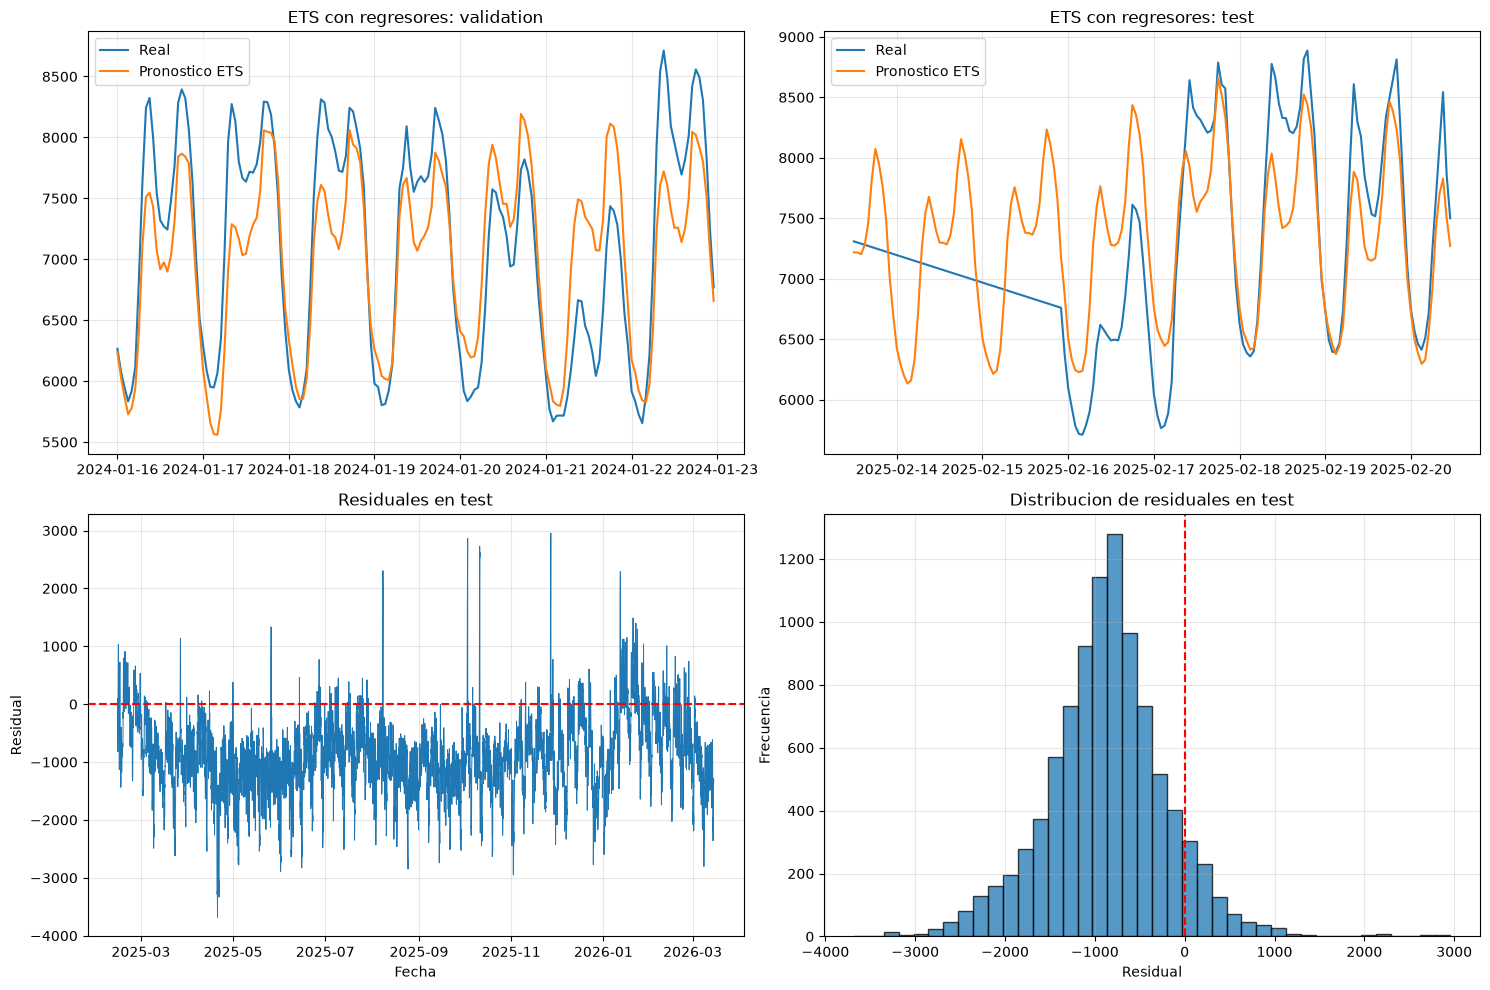

In [11]:
# Diagnostico visual del modelo estructural ETS con regresores
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

validation_window = min(24 * 7, len(val_endog))
axes[0, 0].plot(val_endog.index[:validation_window], val_endog.iloc[:validation_window], label='Real')
axes[0, 0].plot(pred_val_ets.index[:validation_window], pred_val_ets.iloc[:validation_window], label='Pronostico ETS')
axes[0, 0].set_title('ETS con regresores: validation')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(test_endog.index[:validation_window], test_endog.iloc[:validation_window], label='Real')
axes[0, 1].plot(pred_test_ets.index[:validation_window], pred_test_ets.iloc[:validation_window], label='Pronostico ETS')
axes[0, 1].set_title('ETS con regresores: test')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

test_residuals_ets = test_endog.to_numpy() - pred_test_ets.to_numpy()
axes[1, 0].plot(test_endog.index, test_residuals_ets, linewidth=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Residuales en test')
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(test_residuals_ets, bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('Distribucion de residuales en test')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Estimacion y evaluacion del ETS estructural
Se estima `UnobservedComponents` con nivel local, estacionalidad diaria de 24 horas y ocho regresores de generacion. Validation se pronostica con el modelo ajustado en train; despues se reajustan modelo y escalador con train + validation para evaluar test. El Seasonal Naive de 24 horas ofrece una referencia sin regresores. La comparacion de test sigue siendo condicional a conocer la generacion del mismo periodo.

In [ ]:
# Comprobacion de escalado: validation usa scaler train-only; test usa el scaler final train+validation.
validation_scaling_summary = pd.DataFrame({
    'train_scaled_mean': train_exog_scaled.mean(),
    'train_scaled_std': train_exog_scaled.std(ddof=0),
    'validation_scaled_mean': val_exog_scaled.mean(),
    'validation_scaled_std': val_exog_scaled.std(ddof=0),
})
final_scaling_summary = pd.DataFrame({
    'train_validation_scaled_mean': train_val_exog_scaled.mean(),
    'train_validation_scaled_std': train_val_exog_scaled.std(ddof=0),
    'test_scaled_mean': test_exog_scaled.mean(),
    'test_scaled_std': test_exog_scaled.std(ddof=0),
})

print('Escalado usado para evaluar validation:')
display(validation_scaling_summary.round(4))
print('Escalado usado para el modelo final y test:')
display(final_scaling_summary.round(4))

,mean_train,std_train,mean_validation,std_validation,mean_test,std_test
Production,-0.0,1.0,-0.6784,0.9775,-0.6534,1.0677
Nuclear,-0.0,1.0,-0.1435,1.0298,-0.1102,0.9409
Wind,-0.0,1.0,-0.1292,0.9289,-0.1353,0.9159
Hydroelectric,0.0,1.0,-0.4070,0.7412,-0.4900,0.7928
Oil and Gas,-0.0,1.0,0.1283,1.0284,0.1071,1.0896
Coal,0.0,1.0,-1.2624,0.5031,-1.3474,0.5725
Solar,-0.0,1.0,0.3464,1.5025,0.7351,2.0792
Biomass,-0.0,1.0,-0.3920,0.5993,-0.1549,0.8896


## Interpretacion y limites
Compara primero validation para describir el valor de los regresores; consulta test solo como evaluacion final. Si el Structural ETS supera al Seasonal Naive, parte de esa mejora puede depender de conocer la generacion futura. Forward-fill evita usar valores posteriores para imputar, aunque prolonga el ultimo valor observado en cada hueco.

## Ejercicios
1. Compara el nivel local con tendencia local y explica como cambia el pronostico.
2. Ajusta el modelo sin regresores y compara con Seasonal Naive en validation.
3. Diseña una evaluacion operativa en la que los regresores futuros se sustituyan por pronosticos, sin usar sus valores observados.

## Referencias
- [Statsmodels: UnobservedComponents](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.structural.UnobservedComponents.html)
- Hyndman y Athanasopoulos, *Forecasting: Principles and Practice*, modelos de series temporales: https://otexts.com/fpp3/